# Indice composite d'attractivité — 213 zones de Casablanca


Construction d'un **score 0-100** agrégeant 4 dimensions :

1. **Accessibilité** — distances tram, voies primaires/secondaires, temps de trajet vers les pôles économiques (centre-ville, CFC, Maârif, Sidi Maârouf, port).
2. **Aménités de proximité** — écoles, cliniques, commerces, restaurants, banques (rayons 500m / 1km).
3. **Qualité environnementale** — proximité mer / parcs (+), surface verte 1km (+), nuisances 500m (−).
4. **Profil socio-démographique** — taux d'activité (+), part études supérieur (+), taux de chômage (−), taux de croissance population (+).

### Démarche méthodologique

1. Agrégation des observations par zone (`Code Zone`) via la moyenne.
2. Calcul des **4 sous-scores**.
4. Estimation des **poids des dimensions par régression** sur le prix au m².
5. Combinaison linéaire pondérée, puis mise à l'échelle 0-100.

## 1. Imports et chargement

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('data_finale.csv')
df.columns = [c.strip() for c in df.columns]   # nettoyage des espaces parasites

print(f"Observations brutes : {len(df)}")
print(f"Zones uniques       : {df['Code Zone'].nunique()}")
df.head(3)

Observations brutes : 1477
Zones uniques       : 213


,Préfecture,Arrondissement,Code Zone,Zone déchiffrée,Type de bien,État,Condition / Zonage,Prix Terrain au m² (DH),dist_education_min_m,dist_banque_min_m,...,nb_nuisance,Densite_pop_km2,Part_population_15_59_ans,Taille_de_ménage,Taux_activité,Taux_chômage,Part_salariés_parmi_actifs,Taux_analphabétisme,Part_population_niveau_études_supérieur,Taux_croissance
0,Casa-Anfa,Sidi Belyout,CC-SB1,Av. des FAR,Appartement,Ancien,NaN,11000.0,112.0,8.0,...,9.0,13791,61.2,2.9,47.6,19.5,70.1,10.6,21.3,-27.1
1,Casa-Anfa,Sidi Belyout,CC-SB1,Av. des FAR,Appartement,Récent,NaN,14000.0,112.0,8.0,...,9.0,13791,61.2,2.9,47.6,19.5,70.1,10.6,21.3,-27.1
2,Casa-Anfa,Sidi Belyout,CC-SB1,Av. des FAR,Appartement,Neuf,NaN,16000.0,112.0,8.0,...,9.0,13791,61.2,2.9,47.6,19.5,70.1,10.6,21.3,-27.1


In [57]:
df = df[df['Prix Terrain au m² (DH)'] >= 100]

## 2. Agrégation par zone (moyenne)

In [58]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
zones = df.groupby('Code Zone', as_index=False)[num_cols].mean()

# libellés humains pour chaque zone
zone_label = (df.groupby('Code Zone')['Zone déchiffrée']
                .agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])
                .reset_index())
arr_label  = (df.groupby('Code Zone')['Arrondissement']
                .agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])
                .reset_index())
zones = zones.merge(zone_label, on='Code Zone').merge(arr_label, on='Code Zone')

print(f"Lignes après agrégation : {len(zones)} zones")
zones[['Code Zone', 'Arrondissement', 'Prix Terrain au m² (DH)']].head()

Lignes après agrégation : 213 zones


,Code Zone,Arrondissement,Prix Terrain au m² (DH)
0,CC-AF1,Al Fida,11533.333333
1,CC-AF2,Al Fida,13025.000000
2,CC-AF3,Al Fida,13500.000000
3,CC-AF4,Al Fida,13285.714286
4,CC-AF5,Al Fida,15200.000000


## 3. Définition des 4 dimensions

Chaque variable est étiquetée `pos` (plus c'est élevé, mieux c'est) ou `neg` (l'inverse).

In [59]:
DIMENSIONS = {
    'Accessibilite': {
        'dist_tram':                  'neg',
        'dist_voie_primaire_min_m':   'neg',
        'dist_voie_secondaire_min_m': 'neg',
        'temps_transport_centre':     'neg',
        'temps_CFC':                  'neg',
        'temps_Maarif':               'neg',
        'temps_SidiMaarouf':          'neg',
        'temps_port':                 'neg',
    },
    'Amenites': {
        'nb_ecoles_1km':              'pos',
        'nb_sante_1km':               'pos',
        'nb_commerces_1km':           'pos',
        'nb_restaurants_500m':        'pos',
        'nb_banques_1km':             'pos',
    },
    'Environnement': {
        'dist_mer':                   'neg',
        'dist_parc':                  'neg',
        'surface_verte_1km':          'pos',
        'nb_nuisance_500m':           'neg',
    },
    'SocioDemo': {
        'Taux_activité':                              'pos',
        'Part_population_niveau_études_supérieur':    'pos',
        'Taux_chômage':                               'neg',
        'Taux_croissance':                            'pos',
    },
}

# vérification de l'existence des colonnes
all_vars = [v for d in DIMENSIONS.values() for v in d]
missing  = [v for v in all_vars if v not in zones.columns]
assert not missing, f'Colonnes introuvables : {missing}'
print(f"{len(all_vars)} variables réparties sur {len(DIMENSIONS)} dimensions.")

21 variables réparties sur 4 dimensions.


## 4. Normalisation Min-Max + inversion des variables négatives

In [60]:
normalized = pd.DataFrame(index=zones.index)
scaler = MinMaxScaler()

for dim, var_dict in DIMENSIONS.items():
    for var, sign in var_dict.items():
        x_norm = scaler.fit_transform(zones[[var]].astype(float)).flatten()
        if sign == 'neg':
            x_norm = 1.0 - x_norm   # inversion
        normalized[var] = x_norm

print(f"{normalized.shape[1]} variables normalisées dans [0, 1].")
normalized.describe().round(3).T.head(10)

21 variables normalisées dans [0, 1].


,count,mean,std,min,25%,50%,75%,max
dist_tram,213.0,0.616,0.230,0.0,0.446,0.641,0.835,1.0
dist_voie_primaire_min_m,213.0,0.853,0.115,0.0,0.826,0.865,0.905,1.0
dist_voie_secondaire_min_m,213.0,0.825,0.202,0.0,0.851,0.861,0.947,1.0
temps_transport_centre,213.0,0.540,0.245,0.0,0.288,0.585,0.708,1.0
temps_CFC,213.0,0.666,0.252,0.0,0.616,0.747,0.821,1.0
temps_Maarif,213.0,0.656,0.259,0.0,0.546,0.620,0.862,1.0
temps_SidiMaarouf,213.0,0.648,0.251,0.0,0.547,0.711,0.766,1.0
temps_port,213.0,0.571,0.269,0.0,0.352,0.573,0.798,1.0
nb_ecoles_1km,213.0,0.462,0.296,0.0,0.185,0.444,0.667,1.0
nb_sante_1km,213.0,0.257,0.185,0.0,0.138,0.175,0.344,1.0


## 5. Sous-scores thématiques (moyenne intra-dimension)

In [61]:
sub_scores = pd.DataFrame(index=zones.index)
for dim, var_dict in DIMENSIONS.items():
    sub_scores[dim] = normalized[list(var_dict.keys())].mean(axis=1)

sub_scores.describe().round(3)

,Accessibilite,Amenites,Environnement,SocioDemo
count,213.000,213.000,213.000,213.000
mean,0.672,0.294,0.591,0.492
std,0.149,0.215,0.104,0.205
min,0.221,0.022,0.369,0.051
25%,0.638,0.148,0.499,0.321
50%,0.692,0.209,0.587,0.529
75%,0.789,0.293,0.639,0.688
max,0.862,0.880,0.816,0.807


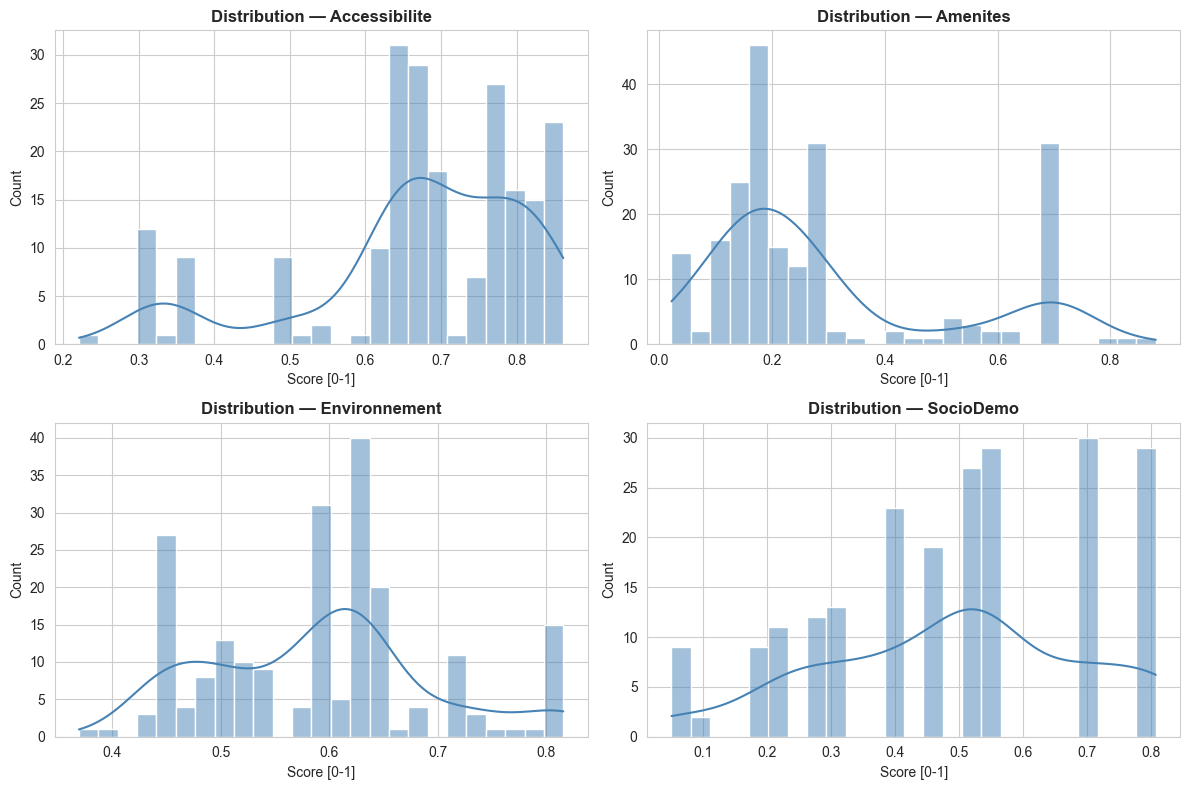

In [62]:
# Visualisation : distribution des 4 sous-scores
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, sub_scores.columns):
    sns.histplot(sub_scores[col], bins=25, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution — {col}', fontsize=12, weight='bold')
    ax.set_xlabel('Score [0-1]')
plt.tight_layout()
plt.show()

## 6. Diagnostic de multicolinéarité (VIF)

In [63]:
X = sub_scores[list(DIMENSIONS.keys())].values
y = zones['Prix Terrain au m² (DH)'].values

vif_data = pd.DataFrame({
    'Dimension': list(DIMENSIONS.keys()),
    'VIF':       [variance_inflation_factor(X, i) for i in range(X.shape[1])]
}).round(2)

vif_data

,Dimension,VIF
0,Accessibilite,16.04
1,Amenites,4.58
2,Environnement,14.58
3,SocioDemo,8.18


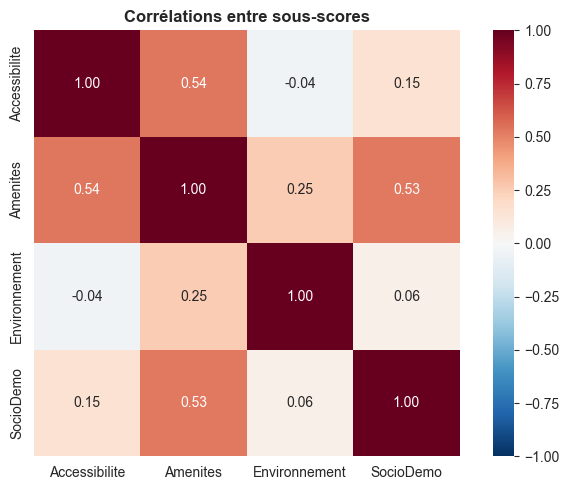

In [64]:
# Matrice de corrélation des sous-scores
corr = sub_scores.corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True)
plt.title('Corrélations entre sous-scores', weight='bold')
plt.tight_layout()
plt.show()

## 7. Régression : poids des dimensions

In [65]:
max_vif = vif_data['VIF'].max()
multicol = max_vif > 5

ols = LinearRegression().fit(X, y)
ols_r2 = r2_score(y, ols.predict(X))

if multicol:
    print(f"Multicolinéarité détectée (VIF max = {max_vif:.1f} > 5) : Ridge")
    ridge = RidgeCV(alphas=np.logspace(-2, 3, 60), cv=5).fit(X, y)
    coefs  = ridge.coef_
    r2     = r2_score(y, ridge.predict(X))
    method = f"Ridge (alpha = {ridge.alpha_:.3g})"
else:
    print(f"Pas de multicolinéarité (VIF max = {max_vif:.1f}) : OLS retenu")
    coefs  = ols.coef_
    r2     = ols_r2
    method = 'OLS'

# Poids = coefficients positifs normalisés (somme = 1)
coefs_pos = np.clip(coefs, a_min=0, a_max=None)
if coefs_pos.sum() == 0:
    coefs_pos = np.abs(coefs)
weights = coefs_pos / coefs_pos.sum()

weights_df = pd.DataFrame({
    'Dimension':        list(DIMENSIONS.keys()),
    'Coefficient brut': coefs.round(2),
    'Poids (%)':        (weights * 100).round(2)
})

print(f"\nMéthode retenue : {method}    R² = {r2:.3f}")
weights_df

Multicolinéarité détectée (VIF max = 16.0 > 5) : Ridge

Méthode retenue : Ridge (alpha = 2.36)    R² = 0.275


,Dimension,Coefficient brut,Poids (%)
0,Accessibilite,5992.38,32.20
1,Amenites,7363.93,39.58
2,Environnement,2451.48,13.17
3,SocioDemo,2799.59,15.05


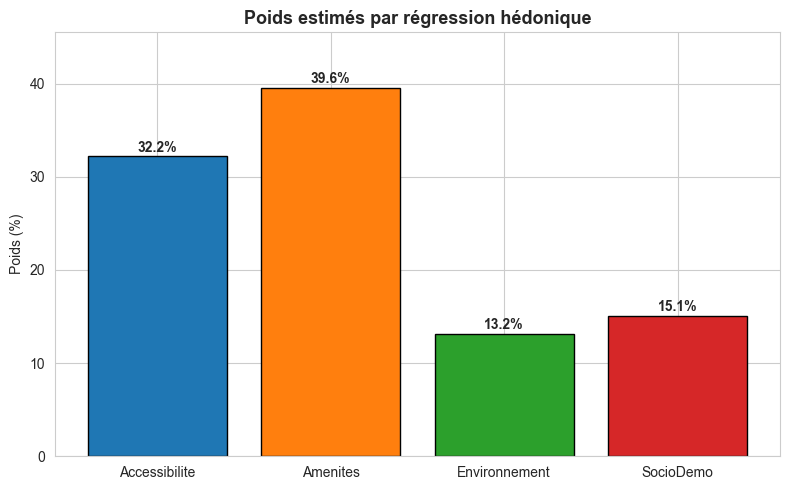

In [66]:
# Visualisation des poids
plt.figure(figsize=(8, 5))
colors = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728']
bars = plt.bar(weights_df['Dimension'], weights_df['Poids (%)'], color=colors, edgecolor='black')
for bar, pct in zip(bars, weights_df['Poids (%)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{pct:.1f}%', ha='center', fontweight='bold')
plt.title('Poids estimés par régression hédonique', weight='bold', fontsize=13)
plt.ylabel('Poids (%)')
plt.ylim(0, max(weights_df['Poids (%)']) * 1.15)
plt.tight_layout()
plt.show()

## 8. Score global d'attractivité [0-100]

In [67]:
score_raw    = sub_scores.values @ weights
score_minmax = (score_raw - score_raw.min()) / (score_raw.max() - score_raw.min())
score_100    = score_minmax * 100

out = pd.DataFrame({
    'Code Zone':            zones['Code Zone'],
    'Zone':                 zones['Zone déchiffrée'],
    'Arrondissement':       zones['Arrondissement'],
    'Prix m² (DH)':         zones['Prix Terrain au m² (DH)'].round(0),
    'Score_Accessibilite':  (sub_scores['Accessibilite']  * 100).round(1),
    'Score_Amenites':       (sub_scores['Amenites']       * 100).round(1),
    'Score_Environnement':  (sub_scores['Environnement']  * 100).round(1),
    'Score_SocioDemo':      (sub_scores['SocioDemo']      * 100).round(1),
    'Score_Attractivite':   score_100.round(1),
}).sort_values('Score_Attractivite', ascending=False).reset_index(drop=True)
out.insert(0, 'Rang', np.arange(1, len(out) + 1))

print(f"Score d'attractivité calculé pour {len(out)} zones.")
out.head(15)

Score d'attractivité calculé pour 213 zones.


,Rang,Code Zone,Zone,Arrondissement,Prix m² (DH),Score_Accessibilite,Score_Amenites,Score_Environnement,Score_SocioDemo,Score_Attractivite
0,1,CC-SB10,"Alsace Lorraine, Ben Jdia, Liberté, Derb Omar,...",Sidi Belyout,18100.0,83.1,88.0,57.2,39.7,100.0
1,2,CC-SB8,Bd Rachidi,Sidi Belyout,20800.0,82.7,81.2,78.6,39.7,99.9
2,3,CC-SB2,Av. Hassan II,Sidi Belyout,25600.0,85.2,78.9,74.3,39.7,98.6
3,4,CC-AN4,Zone délimitée par Av. A - Club de la SODEP (S...,Anfa,13667.0,83.9,69.7,81.2,55.4,97.1
4,5,CC-AN10,El Hank Sud délimité par Av. Tantan (Lot El Ma...,Anfa,15000.0,83.9,69.7,81.2,55.4,97.1
5,6,CC-AN3,La Corniche : de Hôtel le Littoral à Anfa Plac...,Anfa,26375.0,83.9,69.7,81.2,55.4,97.1
6,7,CC-AN6,"Zone délimitée par Ayn Al Gaddid (Sud), Océan ...",Anfa,13000.0,83.9,69.7,81.2,55.4,97.1
7,8,CC-AN9,"El Hank Nord délimité par Av. Tantan (ZI), Qua...",Anfa,22500.0,83.9,69.7,81.2,55.4,97.1
8,9,CC-AN8,Quartier Racine Ouest délimité par Bd Ain Taou...,Anfa,21071.0,83.9,69.7,81.2,55.4,97.1
9,10,CC-AN7,"Quartier Bourgogne Ouest, Hay Tassahoul Sud",Anfa,15611.0,83.9,69.7,81.2,55.4,97.1


In [68]:
out['Prix m² (DH)'].describe().round(0)

count      213.0
mean     14360.0
std       5668.0
min       6071.0
25%      10375.0
50%      13056.0
75%      17042.0
max      45000.0
Name: Prix m² (DH), dtype: float64

In [69]:
# Bottom 10
out.tail(10)

,Rang,Code Zone,Zone,Arrondissement,Prix m² (DH),Score_Accessibilite,Score_Amenites,Score_Environnement,Score_SocioDemo,Score_Attractivite
203,204,CE-SB2,Salmia 2,Sbata,8250.0,51.6,4.4,44.9,23.0,7.2
204,205,CN-SM1,"Hay Anassi, Ard Sefrioui, Hay Assalam 1 et 2, ...",Sidi Moumen,7850.0,35.2,3.5,54.8,46.8,5.7
205,206,CN-SM10,"Hay Sidi Moumen Jdid, Hay Karia, Hay Kapissine...",Sidi Moumen,10150.0,35.2,3.5,54.8,46.8,5.7
206,207,CN-SM8,"Lot Rahmani, Lot Baraka, Lot Madinat Nour, Lot...",Sidi Moumen,9312.0,35.2,3.5,54.8,46.8,5.7
207,208,CN-SM7,"Hay Al Walaâ (Quartier Attacharouk), GH Walili...",Sidi Moumen,10000.0,35.2,3.5,54.8,46.8,5.7
208,209,CN-SM4,"Lot El Hadika, Rce Riad Al Bernoussi, Hay Ennahda",Sidi Moumen,6071.0,35.2,3.5,54.8,46.8,5.7
209,210,CN-SM9,"Hay Sidi Moumen Lakdim, Hay Rekbout, Hay Douma...",Sidi Moumen,9562.0,35.2,3.5,54.8,46.8,5.7
210,211,CN-SM6,"Lot Jaouhara (Jawhara), Rce Jaouhara (Jawhara)",Sidi Moumen,11388.0,35.2,3.5,54.8,46.8,5.7
211,212,CN-SM5,"Lot Warda, Lot Al Kawtar, Lot Sarazan, Lot Sab...",Sidi Moumen,10062.0,35.2,3.5,54.8,46.8,5.7
212,213,CN-SM2,"Hay Al Azhar, Lot Panorama, Rce Al Fajr, Rce A...",Sidi Moumen,8710.0,22.1,4.6,61.3,46.8,0.0


## 9. Visualisations finales

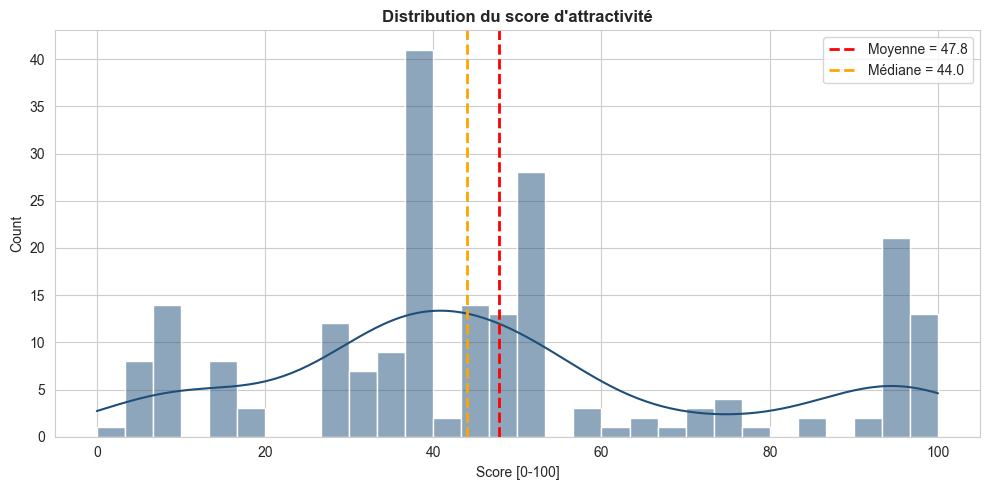

In [70]:
# Distribution du score global
plt.figure(figsize=(10, 5))
sns.histplot(out['Score_Attractivite'], bins=30, kde=True, color='#1F4E78', edgecolor='white')
plt.axvline(out['Score_Attractivite'].mean(), color='red', ls='--', lw=2,
            label=f"Moyenne = {out['Score_Attractivite'].mean():.1f}")
plt.axvline(out['Score_Attractivite'].median(), color='orange', ls='--', lw=2,
            label=f"Médiane = {out['Score_Attractivite'].median():.1f}")
plt.title("Distribution du score d'attractivité", weight='bold')
plt.xlabel('Score [0-100]')
plt.legend()
plt.tight_layout()
plt.show()

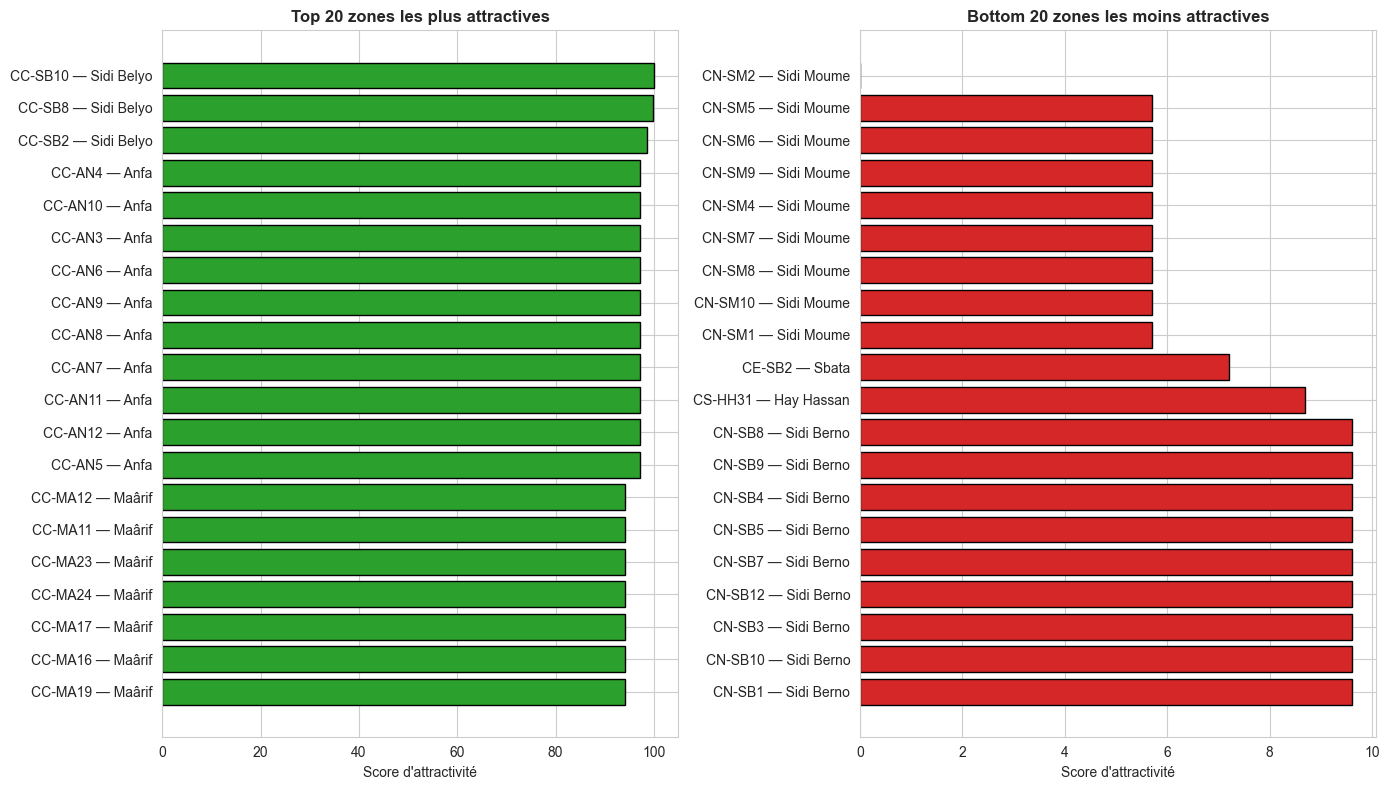

In [71]:
# Top 20 + Bottom 20 — barre horizontale
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

top20 = out.head(20).iloc[::-1]
axes[0].barh(top20['Code Zone'] + ' — ' + top20['Arrondissement'].str[:10],
             top20['Score_Attractivite'], color='#2CA02C', edgecolor='black')
axes[0].set_title('Top 20 zones les plus attractives', weight='bold')
axes[0].set_xlabel('Score d\'attractivité')

bottom20 = out.tail(20)
axes[1].barh(bottom20['Code Zone'] + ' — ' + bottom20['Arrondissement'].str[:10],
             bottom20['Score_Attractivite'], color='#D62728', edgecolor='black')
axes[1].set_title('Bottom 20 zones les moins attractives', weight='bold')
axes[1].set_xlabel('Score d\'attractivité')

plt.tight_layout()
plt.show()

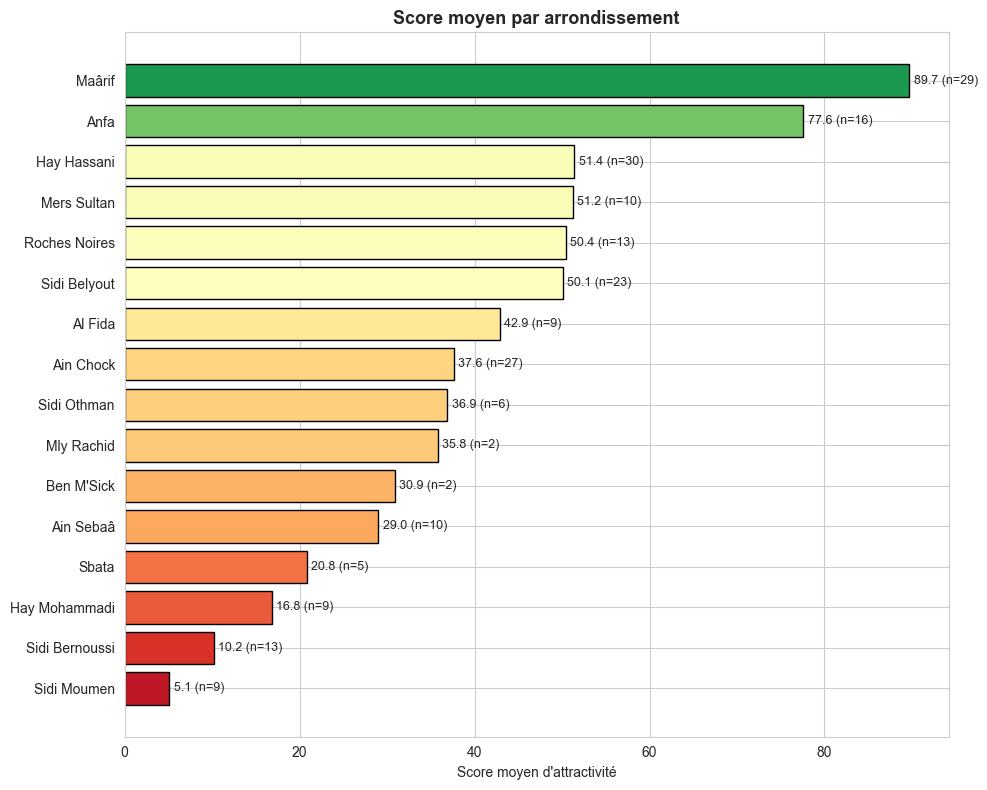

,Nb_zones,Score_moyen,Prix_moyen
Arrondissement,,,
Maârif,29,89.7,19713.2
Anfa,16,77.6,19089.2
Hay Hassani,30,51.4,12475.1
Mers Sultan,10,51.2,15450.7
Roches Noires,13,50.4,13581.0
Sidi Belyout,23,50.1,19944.6
Al Fida,9,42.9,13173.2
Ain Chock,27,37.6,12867.1
Sidi Othman,6,36.9,9223.3


In [72]:
# Score moyen par arrondissement
by_arr = (out.groupby('Arrondissement')
             .agg(Nb_zones=('Code Zone', 'count'),
                  Score_moyen=('Score_Attractivite', 'mean'),
                  Prix_moyen=('Prix m² (DH)', 'mean'))
             .round(1)
             .sort_values('Score_moyen', ascending=False))

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlGn(by_arr['Score_moyen'] / 100)
ax.barh(by_arr.index, by_arr['Score_moyen'], color=colors, edgecolor='black')
ax.set_xlabel('Score moyen d\'attractivité')
ax.set_title('Score moyen par arrondissement', weight='bold', fontsize=13)
ax.invert_yaxis()
for i, (score, n) in enumerate(zip(by_arr['Score_moyen'], by_arr['Nb_zones'])):
    ax.text(score + 0.5, i, f'{score:.1f} (n={n})', va='center', fontsize=9)
plt.tight_layout()
plt.show()

by_arr

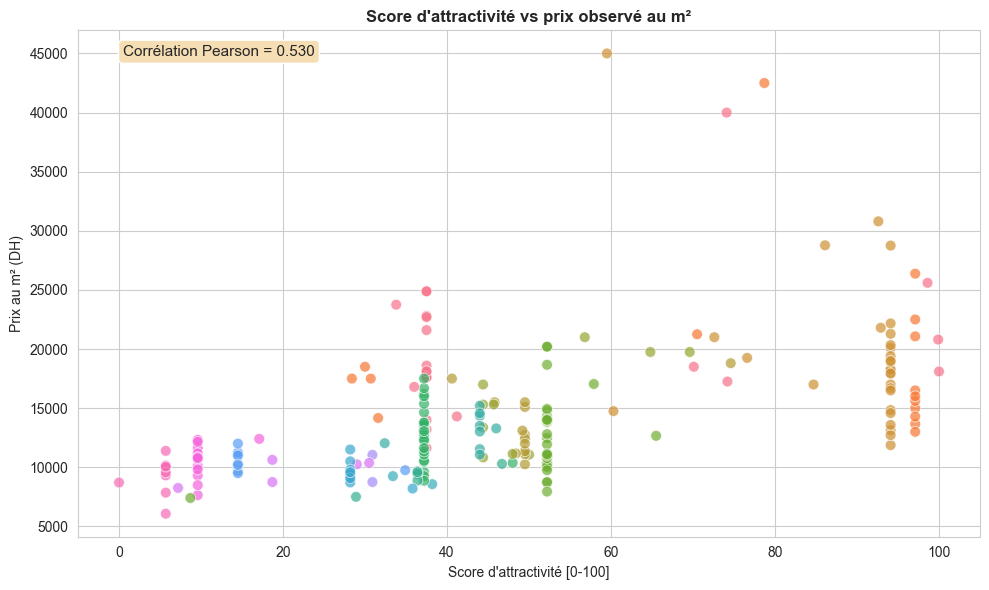

In [73]:
# Score vs Prix — validation de la cohérence
plt.figure(figsize=(10, 6))
sns.scatterplot(data=out, x='Score_Attractivite', y='Prix m² (DH)',
                hue='Arrondissement', alpha=0.7, s=60, legend=False)
plt.title('Score d\'attractivité vs prix observé au m²', weight='bold')
plt.xlabel('Score d\'attractivité [0-100]')
plt.ylabel('Prix au m² (DH)')

# corrélation
corr_score_prix = out[['Score_Attractivite', 'Prix m² (DH)']].corr().iloc[0, 1]
plt.text(0.05, 0.95, f'Corrélation Pearson = {corr_score_prix:.3f}',
         transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(boxstyle='round', facecolor='wheat'))
plt.tight_layout()
plt.show()

## 10. Export

In [74]:
out.to_csv('score_attractivite_zones.csv', index=False, encoding='utf-8-sig')
weights_df.to_csv('poids_dimensions.csv', index=False, encoding='utf-8-sig')
print('Fichiers générés :')
print('  - score_attractivite_zones.csv  ({} zones)'.format(len(out)))
print('  - poids_dimensions.csv')

Fichiers générés :
  - score_attractivite_zones.csv  (213 zones)
  - poids_dimensions.csv
